# 탐색적 데이터 분석(EDA)
- EDA(Exploratory Data Analysis) - 데이터의 구조적 특성을 규명하는 탐색 단계
- 미국 벨 연구소의 통계학자 '존 튜키(John Tukey)'가 창안한 데이터 해석 및 기획 절차
- 수치적 수집과 결과 도출에 앞서, 수집된 정보 자체에 대한 '다각적 관찰 및 직관적 파악'을 관통해야 함을 강조한다
- 정형화된 시각 외에 입체적인 시선으로 데이터 내부의 형태를 점검해야 한다
    - 1) 각 피처(Column)와 데이터 건수(Row)가 상징하는 메타 정보 및 속성 간 상호작용 검토
    - 2) 누락된 데이터(결측치) 가공 및 목적에 부합하는 레코드 선별(Filtering)
    - 3) 그래픽 요소를 통한 분포 및 특성 시각화

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 윈도우 맑은 고딕 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 파일 경로 지정해서 titanic_df에 저장
base_path = r"C:\kdt_0900_pjh\data_analysis\resource\dataset"
file_name = r"titanic.csv"

file_path = os.path.join(base_path, file_name)

titanic_df = pd.read_csv(file_path)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 상관 관계
- ※ 열(Column), 데이터 속성(Attribute), 변수(Variable), 피처(Feature)는 모두 동의어로 혼용된다.
- 특정 수치 간의 상호 연결성, 즉 두 변수가 보여주는 변화 패턴의 유사성을 측정하는 지표이다. 특히 두 변수 사이의 관계가 선형적(Linear) 형태를 띠는지 평가하는 척도로 쓰인다.
- 예를 들어, A 변수의 수치가 상승할 때 B 변수의 수치 역시 동반 상승하는지, 아니면 반대로 하락하는지 파악한다.
- 수치의 증감 경향성을 확인할 수 있어, 전체적인 데이터의 분포 현황과 경향성(Trend)을 파악할 때 핵심적인 역할을 한다.
- 값의 범위는 -1에서 +1 사이의 수치로 산출된다.
- +1에 근접할수록 두 변수 A와 B가 동일한 방향으로 완벽하게 비례하여 움직인다.
- -1에 근접할수록 한 변수가 증가할 때 다른 변수는 감소하는 반비례 양상을 보인다.
- 0에 가까워질수록 두 변수 간에는 어떠한 선형적 연관성도 존재하지 않음을 뜻한다.
- 부호와 상관없이 절대값이 1에 가까워질수록 상관성의 정도가 강하다고 판단한다.
- 참고사항: 단, 높은 상관계수가 곧 두 변수 간의 인과관계를 의미하는 것은 아니다. 연관성이 높다는 사실이 반드시 원인과 결과 관계임을 보장하지는 않는다.

## 타이타닉 데이터셋 컬럼 상세 정리

주피터 노트북에서 전처리를 시작하기 전, 각 변수(Feature)의 의미와 데이터 타입을 파악하기 위한 가이드라인입니다.

| 컬럼명 (Column) | 의미 (Description) | 데이터 타입 | 전처리 및 분석 팁 |
| :--- | :--- | :--- | :--- |
| **PassengerId** | 승객 고유 번호 | 수치형 (Integer) | 단순 일련번호이므로 예측 모델을 만들 때는 보통 **삭제(drop)**합니다. |
| **Survived** | 생존 여부 | 범주형 (Binary) | **0 = 사망, 1 = 생존**. 우리가 최종적으로 예측해야 하는 **목표 변수(Target)**입니다. |
| **Pclass** | 티켓 등급 (사회적 지위) | 범주형 (Ordinal) | **1 = 1등석, 2 = 2등석, 3 = 3등석**. 숫자로 되어 있지만 등급을 나타내는 범주형 데이터입니다. |
| **Name** | 승객 이름 | 문자열 (Text) | `Mr.`, `Mrs.`, `Miss.` 같은 **칭호(Title)를 추출**하여 파생 변수로 활용할 수 있습니다. |
| **Sex** | 성별 | 범주형 (Text) | `male`(남성), `female`(여성). 문자열이므로 머신러닝 모델 학습 전 **숫자(0 또는 1)로 인코딩**해야 합니다. |
| **Age** | 나이 | 수치형 (Continuous) | **결측치(NaN)가 존재**합니다. 전체 평균이나 칭호별 평균/중앙값으로 채우는 연습을 합니다. |
| **SibSp** | 동반한 형제 자매 / 배우자 수 | 수치형 (Discrete) | 함께 탑승한 형제, 자매, 배우자의 수입니다. 파생 변수를 만들 때 활용됩니다. |
| **Parch** | 동반한 부모 / 자식 수 | 수치형 (Discrete) | 함께 탑승한 부모, 자녀의 수입니다. `SibSp`와 더해 가족 크기를 계산할 수 있습니다. |
| **Ticket** | 티켓 번호 | 문자열 (Text) | 알파벳과 숫자가 섞인 무작위 문자열입니다. 정제하기 까다로워 보통 **삭제**합니다. |
| **Fare** | 여객 운임 (티켓 요금) | 수치형 (Continuous) | 데이터 분포가 한쪽으로 심하게 치우쳐(Skewed) 있어 **로그 변환(Log Transformation)**을 주로 적용합니다. |
| **Cabin** | 객실 번호 | 문자열 (Text) | **결측치가 70% 이상으로 매우 많습니다.** 아예 삭제하거나, 앞 글자(알파벳 구역)만 추출해 활용합니다. |
| **Embarked** | 탑승 항구명 | 범주형 (Text) | 승객이 배를 탄 항구입니다. (**C** = 셰르부르, **Q** = 퀸즈타운, **S** = 사우샘프턴). 결측치가 2개 존재합니다. |

In [16]:
titanic_df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


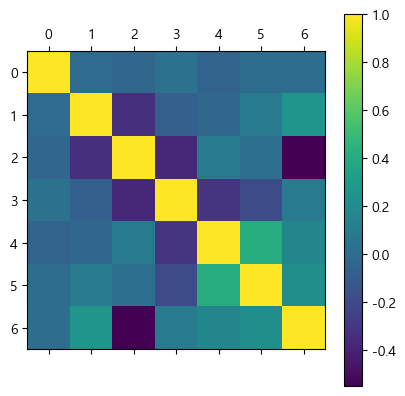

In [17]:
plt.matshow(titanic_df.corr(numeric_only=True))
plt.colorbar()
plt.show()

In [18]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [29]:
titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [21]:
titanic_df.columns.unique()

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [4]:
titanic_df_v1 = titanic_df.drop(["PassengerId", "Ticket", "Cabin", "Embarked"], axis=1)
titanic_df_v1

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000


## 계획 수립
1. 분류형: Survived, Pclass, Name, Sex
   - 최빈값, 컬럼 생성
1. 수치형: Age, SibSp, Parch, Fare
   - 평균값, 중앙값

## 이상치, 결측치, 중복값 확인 대체

In [26]:
# NaN 값이 몇 개 있는지 확인
titanic_df_v1.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
dtype: int64

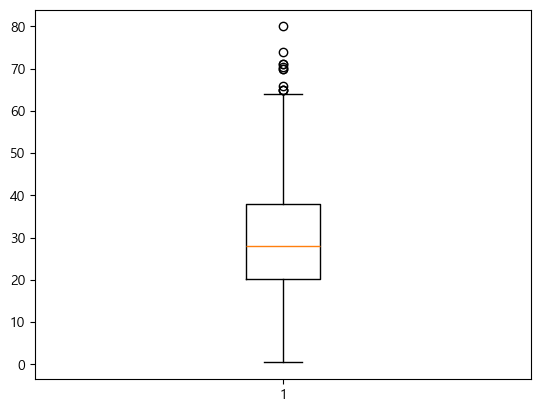

In [30]:
plt.boxplot(titanic_df_v1["Age"].dropna())
plt.show()

In [34]:
age_median = titanic_df_v1["Age"].median()
age_mean = titanic_df_v1["Age"].mean()

print(f"나이 중앙값: {age_median}\n나이 평균값: {age_mean}")

나이 중앙값: 28.0
나이 평균값: 29.69911764705882


In [40]:
Q3 = titanic_df_v1["Age"].quantile(0.75)
Q1 = titanic_df_v1["Age"].quantile(0.25)
IQR = Q3 - Q1

max_outlier = Q3 + (1.5 * IQR)
min_outlier = Q1 - (1.5 * IQR)

print(Q3)
print(Q1)
print(IQR)
print(max_outlier)
print(min_outlier)

38.0
20.125
17.875
64.8125
-6.6875


In [62]:
# titanic_df_v1.loc[titanic_df_v1["Age"].idxmin(), "Age"] = meage_median
# 나이가 실수인 건 영유아일 가능성이 있다.
titanic_df_v1.loc[803, "Age"] = 0

In [46]:
titanic_df_v1.iloc[803]

Survived                                  1
Pclass                                    3
Name        Thomas, Master. Assad Alexander
Sex                                    male
Age                                    28.0
SibSp                                     0
Parch                                     1
Fare                                 8.5167
Name: 803, dtype: object

In [65]:
titanic_df_v1[titanic_df_v1["Age"] < 10]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare
7,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,21.0750
10,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.00,1,1,16.7000
16,0,3,"Rice, Master. Eugene",male,2.00,4,1,29.1250
24,0,3,"Palsson, Miss. Torborg Danira",female,8.00,3,1,21.0750
43,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.00,1,2,41.5792
...,...,...,...,...,...,...,...,...
827,1,2,"Mallet, Master. Andre",male,1.00,0,2,37.0042
831,1,2,"Richards, Master. George Sibley",male,0.83,1,1,18.7500
850,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.00,4,2,31.2750
852,0,3,"Boulos, Miss. Nourelain",female,9.00,1,1,15.2458


In [63]:
titanic_df_v1.loc[803]

Survived                                  1
Pclass                                    3
Name        Thomas, Master. Assad Alexander
Sex                                    male
Age                                     0.0
SibSp                                     0
Parch                                     1
Fare                                 8.5167
Name: 803, dtype: object

In [66]:
titanic_df_v1["Age"].isna().sum()

177

In [67]:
titanic_df_v1["Age"] = titanic_df_v1["Age"].fillna(age_median)

In [69]:
titanic_df_v1.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
dtype: int64

In [73]:
titanic_df_v1["Age"] = titanic_df_v1["Age"].astype(int)

In [79]:
titanic_df_v1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       891 non-null    int32  
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
dtypes: float64(1), int32(1), int64(4), object(2)
memory usage: 52.3+ KB


## 가설 1. 영화에서도 여성이 먼저 구출되었다. 실제 데이터도 여성의 생존률이 높지 않을까?

In [84]:
print(titanic_df_v1.groupby("Sex")["Survived"].mean())
print(titanic_df_v1.groupby("Sex")["Survived"].sum())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Sex
female    233
male      109
Name: Survived, dtype: int64


In [85]:
titanic_df_v1.groupby("Sex")["Survived"].agg(["count", "mean", "sum"])

,count,mean,sum
Sex,,,
female,314,0.742038,233
male,577,0.188908,109


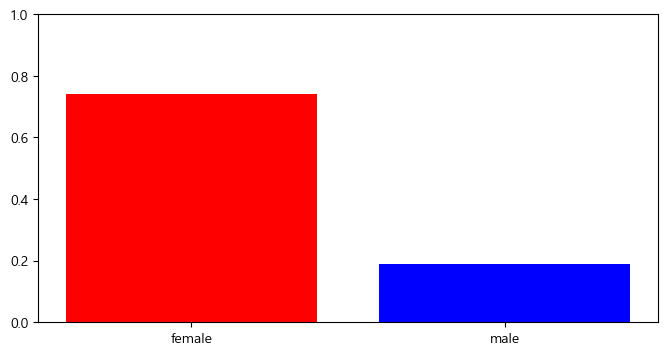

In [97]:
sex_survived = titanic_df_v1.groupby("Sex")["Survived"].mean()

plt.figure(figsize=(8, 4))
plt.bar(sex_survived.index, sex_survived.values, color=["r", "b"])
plt.ylim(0, 1)
plt.show()

# seaborn
- Matplotlib 위에 구축되어서 데이터를 더 간단하고 쉽게 시각화 할 수 있게 도와주는 데이터 시각화 라이브러리이다.
- 주로 통계적인 데이터 및 시각화에 초점이 맞춰져 있으며, 차트, 스타일을 제공한다.

[seaborn 공식링크](https://seaborn.pydata.org)

In [99]:
import seaborn as sns

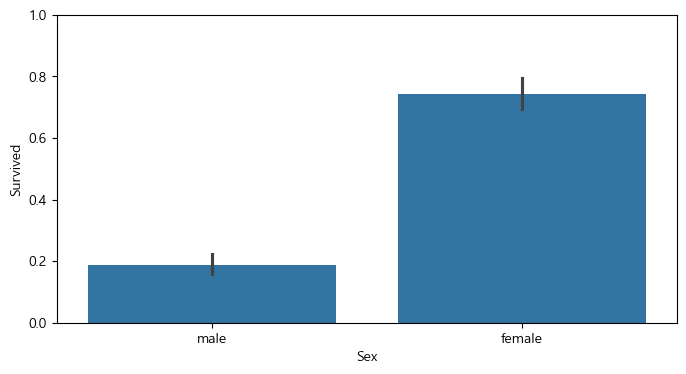

In [107]:
plt.figure(figsize=(8, 4))
sns.barplot(x = "Sex", y = "Survived", data = titanic_df_v1)
plt.ylim(0, 1)
plt.show()

## 가설 1. 검증
- 영화에서도 여성이 먼저 구출되었다. 실제 데이터도 여성의 생존률이 높지 않을까?
- 검증: 여성의 생존율이 74.2%로 남성의 생존률 18.9%보다 약 4배 가까운 정도로 압도적으로 높다.

# (각자) 가설2. 객실 등급이 높은 사람들의 생존률이 낮은 등급 사람들보다 높을까?

In [5]:
titanic_df_v2 = titanic_df.drop(["PassengerId", "Ticket", "Cabin", "Embarked"], axis=1)

In [125]:
print(titanic_df_v2.groupby("Pclass")["Survived"].agg(["count", "sum", "mean"]))

        count  sum      mean
Pclass                      
1         216  136  0.629630
2         184   87  0.472826
3         491  119  0.242363


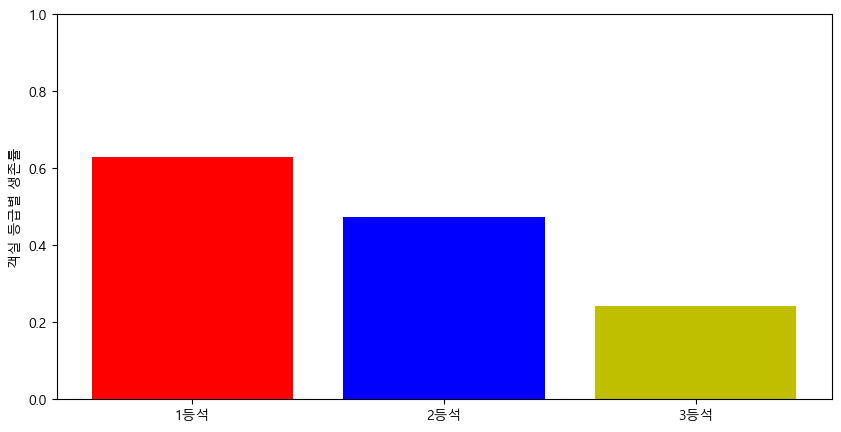

In [134]:
pclass_survived = titanic_df_v2.groupby("Pclass")["Survived"].mean()

plt.figure(figsize=(10, 5))
plt.bar(pclass_survived.index, pclass_survived.values, color=["r", "b", "y"])
plt.xticks([1, 2, 3], ['1등석', '2등석', '3등석'])
plt.ylabel("객실 등급별 생존률")
plt.ylim(0, 1)
plt.show()

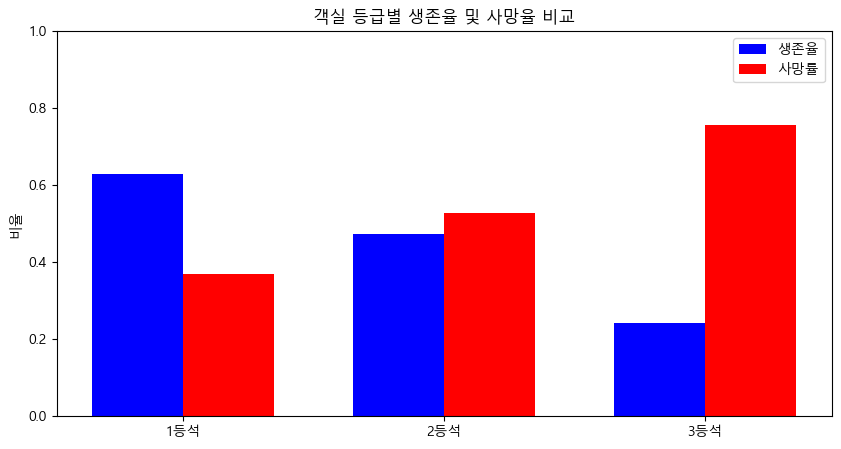

In [9]:
# 1. 데이터 계산 (기존 데이터 기반으로 사망률 추가 계산)
pclass_survived = titanic_df_v2.groupby("Pclass")["Survived"].mean()
pclass_dead = 1 - pclass_survived  # 사망률 계산

# 2. X축 위치 및 두께 설정
x = np.arange(len(pclass_survived.index))  # [0, 1, 2] 위치 생성
width = 0.35  # 막대 두께

plt.figure(figsize=(10, 5))

# 3. 막대 2개를 각각 width/2만큼 왼쪽(-), 오른쪽(+)으로 밀어서 그리기
plt.bar(x - width/2, pclass_survived.values, width=width, color="b", label="생존율")
plt.bar(x + width/2, pclass_dead.values, width=width, color="r", label="사망률")

# 4. 스타일링 및 축 설정
plt.xticks(x, ['1등석', '2등석', '3등석'])  # 정중앙[0, 1, 2] 위치에 글자 배치
plt.ylabel("비율")
plt.title("객실 등급별 생존율 및 사망율 비교")
plt.ylim(0, 1)
plt.legend()  # 어떤 막대가 생존/사망인지 알려주는 범례 추가
plt.show()

# 가설 3. 부모가 같이 탑승한 생존률과 혼자 탑승한 탑승객의 생존률은 차이가 있다.

# 가설 4. 나이가 평균보다 어리면 많이 살아남았을 것이다.

# 가설 5. 객실이 1등급은 나이가 많은 사람들이 많았을 것이다.

# 가설 6. 티켓을 비싸게 구매한 승객이라면 생존율이 높았을 것이다.

In [17]:
titanic_df["FareGroup"] = pd.qcut(titanic_df["Fare"], q=4, labels=["하위 25%", "중위 25%", "중상위 25%", "상위 25%"])

fare_survived = titanic_df.groupby("FareGroup", observed=False)["Survived"].mean()

plt.figure(figsize=(10, 5))

fate_survived.plot(kind="bar", color=["red", "orange", "yellow", "green"])

plt.title("요금 구간별 평균 생존율")
plt.xlabel("요금 구간")
plt.ylabel("생존률")
plt.ylim(0, 1)
plt.grid()
plt.show()

## 검증
- 요금 상위 25% 승객의 생존률이 약 58%, 하위 25% 승객의 생존률은 20%로 약 3배 정도 차이가 난다.
- 티켓 요금을 비싸게 구매한 승객이라면 생존률이 높을 것이다 -> 참